In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

# Milestone 2

In [1]:
!pip install librosa --quiet

In [4]:
import os
import librosa
import numpy as np
import pandas as pd

from tqdm import tqdm

In [5]:
TRAIN_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

In [6]:
data = []

genres = os.listdir(TRAIN_PATH)

for genre in genres:

    genre_path = os.path.join(TRAIN_PATH, genre)

    for song in os.listdir(genre_path):

        song_path = os.path.join(genre_path, song)

        for stem in ["drums.wav", "vocals.wav", "bass.wav", "others.wav"]:

            path = os.path.join(song_path, stem)

            data.append({

                "genre": genre,
                "song": song,
                "stem": stem,
                "path": path

            })


df = pd.DataFrame(data)

df.head()

,genre,song,stem,path
0,disco,disco.00052,drums.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
1,disco,disco.00052,vocals.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
2,disco,disco.00052,bass.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
3,disco,disco.00052,others.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
4,disco,disco.00098,drums.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...


In [7]:
durations = []

for path in tqdm(df[df.genre=="jazz"].path):

    try:

        y, sr = librosa.load(path, sr=None)

        duration = librosa.get_duration(y=y, sr=sr)

        durations.append(duration)

    except:
        pass


mean_jazz_duration = np.mean(durations)

print("ANSWER:", mean_jazz_duration)

  1%|          | 3/400 [00:15<23:52,  3.61s/it]  /tmp/ipykernel_55/3243660722.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 400/400 [00:46<00:00,  8.64it/s]


ANSWER: 30.032979591836725


In [8]:
sample_rates = set()

for path in tqdm(df.path):

    try:

        y, sr = librosa.load(path, sr=None)

        sample_rates.add(sr)

    except:
        pass


print("ANSWER:", sorted(sample_rates))

  0%|          | 3/4000 [00:00<09:42,  6.86it/s]/tmp/ipykernel_55/2790294033.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)
100%|██████████| 4000/4000 [05:17<00:00, 12.60it/s]

ANSWER: [44100]


In [9]:
corrupted = 0

for path in tqdm(df.path):

    try:

        if os.path.getsize(path) == 0:

            corrupted += 1

        else:

            y, sr = librosa.load(path, sr=None)

    except:

        corrupted += 1


print("ANSWER:", corrupted)

100%|██████████| 4000/4000 [02:44<00:00, 24.35it/s]

ANSWER: 1000


In [10]:
peak_db = []

vocals = df[df.stem=="vocals.wav"]

for path in tqdm(vocals.path):

    try:

        y, sr = librosa.load(path, sr=None)

        peak = np.max(np.abs(y))

        db = librosa.amplitude_to_db(np.array([peak]))

        peak_db.append(db[0])

    except:
        pass


print("ANSWER:", np.mean(peak_db))

100%|██████████| 1000/1000 [00:45<00:00, 21.83it/s]

ANSWER: -12.494921


In [11]:
centroids = []

blues = df[df.genre=="blues"]

for path in tqdm(blues.path):

    try:

        y, sr = librosa.load(path, sr=None)

        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

        centroids.append(np.mean(centroid))

    except:
        pass


print("ANSWER:", np.mean(centroids))

  1%|          | 3/400 [00:01<03:05,  2.14it/s]/tmp/ipykernel_55/1462427343.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 400/400 [00:47<00:00,  8.36it/s]

ANSWER: 2533.222557601464


In [12]:
genre_centroid = {}

for genre in genres:

    values = []

    temp = df[df.genre==genre]

    for path in temp.path:

        try:

            y, sr = librosa.load(path, sr=None)

            centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

            values.append(np.mean(centroid))

        except:
            pass


    genre_centroid[genre] = np.mean(values)


print(genre_centroid)

print("\nANSWER:", max(genre_centroid, key=genre_centroid.get))

/tmp/ipykernel_55/2507330758.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)


{'disco': np.float64(2675.865413543104), 'metal': np.float64(2642.901964664897), 'reggae': np.float64(2585.51188985418), 'blues': np.float64(2533.222557601464), 'rock': np.float64(2493.251184828568), 'classical': np.float64(1763.62385572235), 'jazz': np.float64(2881.9880487740643), 'hiphop': np.float64(2259.479860924235), 'country': np.float64(2577.7795005433104), 'pop': np.float64(2734.3861923143763)}

ANSWER: jazz


In [13]:
silence_count = 0

for path in tqdm(df.path):

    try:

        y, sr = librosa.load(path, sr=None)

        first_half_sec = y[:int(sr*0.5)]

        if np.max(np.abs(first_half_sec)) < 0.001:

            silence_count += 1

    except:
        pass


print("ANSWER:", silence_count)

  0%|          | 2/4000 [00:00<03:22, 19.70it/s]/tmp/ipykernel_55/2927203337.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)
100%|██████████| 4000/4000 [02:53<00:00, 23.11it/s]

ANSWER: 533


/tmp/ipykernel_55/1485137573.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_cla

Accuracy: 0.1900
Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



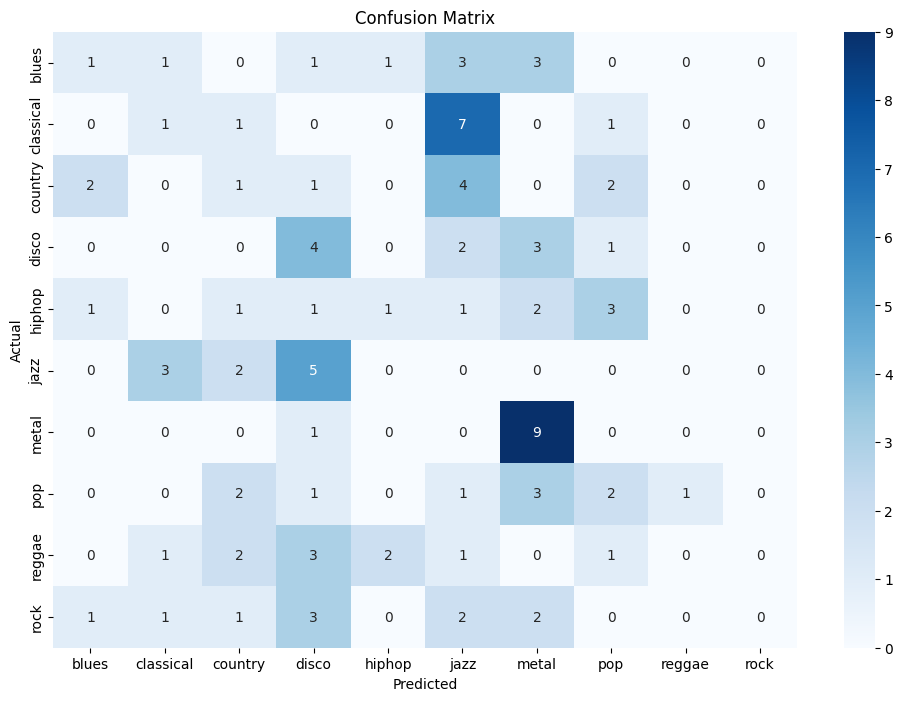


TRUE POSITIVES:
{'blues': np.int64(1), 'classical': np.int64(1), 'country': np.int64(1), 'disco': np.int64(4), 'hiphop': np.int64(1), 'jazz': np.int64(0), 'metal': np.int64(9), 'pop': np.int64(2), 'reggae': np.int64(0), 'rock': np.int64(0)}

FALSE NEGATIVES:
{'blues': np.int64(9), 'classical': np.int64(9), 'country': np.int64(9), 'disco': np.int64(6), 'hiphop': np.int64(9), 'jazz': np.int64(10), 'metal': np.int64(1), 'pop': np.int64(8), 'reggae': np.int64(10), 'rock': np.int64(10)}

Genre with highest TP: metal
Genre with lowest FN: metal


In [14]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

'''
YOUR CODE HERE

y_pred = # COMPUTE PREDICTED VALUES
macro_f1 = # COMPUTE VALIDATION MACRO F1 SCORE
cm = # COMPUTE CONFUSION MATRIX
cr = # COMPUTE CLASSIFICATION REPORT

'''
#.................................................................
# Predict
y_pred = clf.predict(X_val)

# Macro F1
macro_f1 = f1_score(y_val, y_pred, average='macro')

# Confusion matrix
cm = confusion_matrix(y_val, y_pred, labels=GENRES)

# Classification report
cr = classification_report(y_val, y_pred, labels=GENRES)

# Accuracy
accuracy = np.mean(y_pred == y_val)

print(f"Accuracy: {accuracy:.4f}")
#.................................................................

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

'''
YOUR CODE HERE

Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
'''
#.................................................................................
# Confusion matrix visualization

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=GENRES,
    yticklabels=GENRES,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# Compute TP TN FP FN

TP = {}
TN = {}
FP = {}
FN = {}

total = np.sum(cm)

for i, genre in enumerate(GENRES):

    TP[genre] = cm[i,i]

    FN[genre] = np.sum(cm[i,:]) - cm[i,i]

    FP[genre] = np.sum(cm[:,i]) - cm[i,i]

    TN[genre] = total - (TP[genre] + FP[genre] + FN[genre])


print("\nTRUE POSITIVES:")
print(TP)

print("\nFALSE NEGATIVES:")
print(FN)


# Find highest TP genre

highest_tp_genre = max(TP, key=TP.get)

print("\nGenre with highest TP:", highest_tp_genre)


# Find lowest FN genre

lowest_fn_genre = min(FN, key=FN.get)

print("Genre with lowest FN:", lowest_fn_genre)
#.................................................................................

In [15]:
report_dict = classification_report(y_val, y_pred, output_dict=True)

print("\nANSWERS FOR SUBMISSION:\n")

print("Validation Macro F1 Score:", macro_f1)

print("Precision of hiphop:", report_dict['hiphop']['precision'])

print("Recall of pop:", report_dict['pop']['recall'])

print("Accuracy:", accuracy)

print("Highest TP genre:", highest_tp_genre)

print("Lowest FN genre:", lowest_fn_genre)


ANSWERS FOR SUBMISSION:

Validation Macro F1 Score: 0.15230042016806722
Precision of hiphop: 0.25
Recall of pop: 0.2
Accuracy: 0.19
Highest TP genre: metal
Lowest FN genre: metal


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
